# 03. Baseline LSTM 모델 학습

용해탱크 KPI MLOps v1 — Notebook 기반 모델 개발

## 학습 목표

- 전처리된 3차원 시퀀스를 LSTM에 입력한다.
- 클래스 가중치로 NG 미탐에 더 큰 비용을 반영한다.
- 검증 손실을 기준으로 조기 종료한다.
- 최적 모델과 학습 이력을 저장한다.

In [1]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data/processed"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

QUICK_RUN = False
EPOCHS = 2 if QUICK_RUN else 30
BATCH_SIZE = 256
NG_CLASS_WEIGHT = 3.0

In [2]:
X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_validation = np.load(DATA_DIR / "X_validation.npy")
y_validation = np.load(DATA_DIR / "y_validation.npy")

print("train:", X_train.shape, y_train.shape)
print("validation:", X_validation.shape, y_validation.shape)
print("train NG ratio:", y_train.mean())

train: (40320, 10, 3) (40320,)
validation: (10080, 10, 3) (10080,)
train NG ratio: 0.311235119047619


In [3]:
model = keras.Sequential([
    keras.layers.Input(shape=X_train.shape[1:]),
    keras.layers.LSTM(32, activation="tanh"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(curve="PR", name="pr_auc")],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(ARTIFACT_DIR / "model.keras", monitor="val_loss", save_best_only=True),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight={0: 1.0, 1: NG_CLASS_WEIGHT},
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3112 - loss: 1.1066 - pr_auc: 0.3193 - val_accuracy: 0.2884 - val_loss: 0.7725 - val_pr_auc: 0.3014
Epoch 2/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3335 - loss: 1.0936 - pr_auc: 0.3831 - val_accuracy: 0.2884 - val_loss: 0.7850 - val_pr_auc: 0.3006
Epoch 3/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3460 - loss: 1.0777 - pr_auc: 0.4192 - val_accuracy: 0.3717 - val_loss: 0.7745 - val_pr_auc: 0.3001
Epoch 4/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3781 - loss: 1.0779 - pr_auc: 0.4164 - val_accuracy: 0.3004 - val_loss: 0.7952 - val_pr_auc: 0.2991


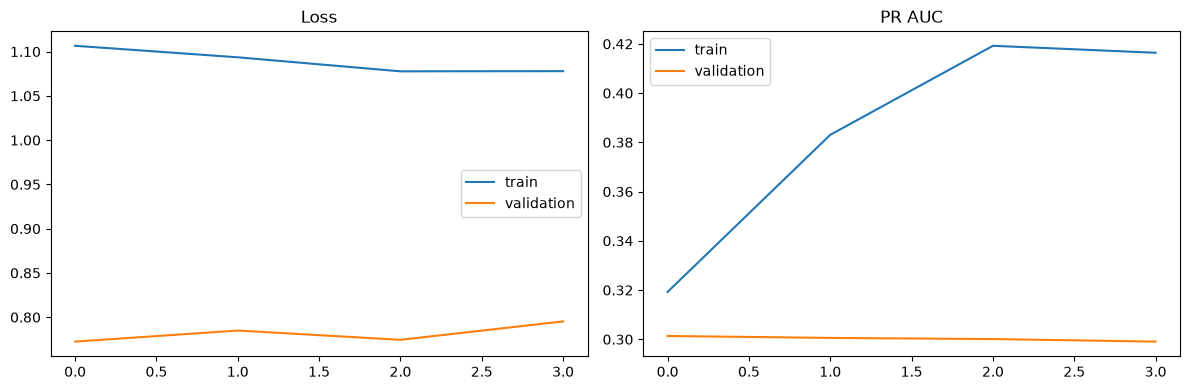

best model: E:\academy\AI-DL\melting-tank-kpi-mlops_notebook_v1.0.0\artifacts\model.keras


In [5]:
history_data = {key: [float(value) for value in values] for key, values in history.history.items()}
(ARTIFACT_DIR / "history.json").write_text(json.dumps(history_data, indent=2), encoding="utf-8")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history.history["pr_auc"], label="train")
axes[1].plot(history.history["val_pr_auc"], label="validation")
axes[1].set_title("PR AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

print("best model:", ARTIFACT_DIR / "model.keras")